# 2D Coulomb Gas Metropolis Notebook

This notebook reorganizes the earlier script into sections and ties the simulation choices to the uploaded papers.

## Literature notes motivating the code

We simulate the **symmetric two-component 2D Coulomb gas** with hard core:
\[
u_{ij}=
\begin{cases}
-\,q_i q_j \, (K/T)\,\ln(r_{ij}/\sigma), & r_{ij}\ge \sigma\\
+\infty, & r_{ij}<\sigma
\end{cases}
\]
with \(q_i=\pm 1\).

This follows the standard hard-core logarithmic Coulomb gas setup discussed in the uploaded papers:

- Orkoulas & Panagiotopoulos (1996): the model is a two-component hard-disk Coulomb gas with
  \(u_{ij} = - q_i q_j D^{-1}\ln(r_{ij}/s)\) for \(r_{ij}>s\), and the KT line starts at \(T^\*=1/4\) at zero density. They also report that at low reduced temperatures the KT line turns into a **first-order dielectric vapor / conducting liquid coexistence line** near a critical point. 

- Caillol & Levesque (1986): at very low densities they find the expected KT transition, while at moderate densities the transition becomes **first order between a dielectric gas and a conductive liquid**. 

- Hansen & Viot (1985): for the symmetric 2D Coulomb gas they emphasize **pair formation** and a “chemical equilibrium” between tightly bound ion pairs and free ions, which is exactly the main structure this notebook tries to visualize. 

- Caillol et al. (1982) is mainly about the **one-component plasma**, but it is useful methodologically because it explains why long-range logarithmic interactions are numerically delicate and why sphere/Ewald approaches are often preferred over the simplest planar local-update simulations. 

## What this notebook is and is not

This notebook is for **visual exploration**:
- snapshots,
- opposite-charge distance histograms,
- close-pair fraction,
- nearest opposite-charge distance.

It is **not** a precision phase-diagram code. It uses:
- fixed particle number,
- local Metropolis moves,
- minimal-image periodic boundaries,
- no Ewald sum,
- and it **ignores the extra** \(T\ln(2\cosh(\cdots))\) term as requested.

So this is good for seeing **pairing vs plasma-like behavior**, but not for making a sharp claim about the true transition line.


## Imports and main parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path

rng = np.random.default_rng(42)

# -----------------------------
# Main simulation parameters
# -----------------------------
L = 36.0                 # square box length
N_pairs = 18             # number of + and number of - charges
sigma = 1.0              # hard-core diameter / short-distance cutoff
move_scale = 1.5         # proposal displacement scale
n_eq = 1200              # equilibration sweeps
n_prod = 600             # production sweeps
sample_every = 10
frame_every = 10

# Scan in coupling K/T
K_over_T_values = [0.6, 1.2, 2.0, 3.0, 4.5]

# Diagnostic threshold for saying a (+,-) pair is "close"
pair_threshold = 2.5 * sigma

outdir = Path("cg2d_outputs")
outdir.mkdir(exist_ok=True)

print("Output folder:", outdir.resolve())

Output folder: /Users/kai/Downloads/2D Coulumb gas research/cg2d_outputs


## Geometry and energetics

We use minimal-image periodic boundaries.  
The pair energy is dimensionless and corresponds to \(\beta U\):
\[
\beta U_{ij} = -(K/T)\,q_i q_j \ln(r_{ij}/\sigma).
\]

The hard core at \(r<\sigma\) is important. Without it, the opposite charges collapse, which is also emphasized in the literature on the 2D Coulomb gas. fileciteturn2file16turn2file2


In [2]:
def pbc_delta(dx, L):
    return dx - L * np.round(dx / L)

def displacement(r1, r2, L):
    return pbc_delta(r1 - r2, L)

def distance(r1, r2, L):
    d = displacement(r1, r2, L)
    return np.sqrt(np.dot(d, d))

def pair_energy(qi, qj, rij, K_over_T, sigma):
    if rij < sigma:
        return np.inf
    return -K_over_T * qi * qj * np.log(rij / sigma)

def total_energy(pos, q, K_over_T, sigma, L):
    E = 0.0
    N = len(q)
    for i in range(N):
        for j in range(i + 1, N):
            rij = distance(pos[i], pos[j], L)
            eij = pair_energy(q[i], q[j], rij, K_over_T, sigma)
            if not np.isfinite(eij):
                return np.inf
            E += eij
    return E

def particle_energy(i, trial_pos_i, pos, q, K_over_T, sigma, L):
    Ei = 0.0
    qi = q[i]
    for j in range(len(q)):
        if j == i:
            continue
        rij = distance(trial_pos_i, pos[j], L)
        eij = pair_energy(qi, q[j], rij, K_over_T, sigma)
        if not np.isfinite(eij):
            return np.inf
        Ei += eij
    return Ei

## Initialization

In [3]:
def initialize_positions(L, N_pairs, sigma, max_tries=100000):
    N = 2 * N_pairs
    pos = []
    for _ in range(max_tries):
        if len(pos) == N:
            break
        candidate = rng.uniform(0, L, size=2)
        ok = True
        for p in pos:
            if distance(candidate, np.array(p), L) < sigma:
                ok = False
                break
        if ok:
            pos.append(candidate)
    if len(pos) < N:
        raise RuntimeError("Failed to place all particles without overlap.")
    pos = np.array(pos, dtype=float)

    q = np.array([+1] * N_pairs + [-1] * N_pairs, dtype=int)
    rng.shuffle(q)
    return pos, q

## Observables

The papers suggest looking directly at **pair formation** and **bound vs unbound structure**.  
So instead of trying to estimate a full dielectric constant in this simplified notebook, we track:

- nearest opposite-charge distance,
- greedy fraction of particles in close \((+,-)\) pairs,
- histogram of all \((+,-)\) separations,
- a crude dipole proxy.

These are qualitative diagnostics motivated especially by Hansen–Viot’s discussion of pair formation. fileciteturn2file9turn2file4


In [4]:
def nearest_opposite_distances(pos, q, L):
    vals = []
    for i in range(len(q)):
        best = np.inf
        for j in range(len(q)):
            if q[j] == -q[i]:
                rij = distance(pos[i], pos[j], L)
                if rij < best:
                    best = rij
        vals.append(best)
    return np.array(vals)

def greedy_pair_fraction(pos, q, L, threshold):
    plus = list(np.where(q == +1)[0])
    minus = list(np.where(q == -1)[0])

    pairs = []
    for i in plus:
        for j in minus:
            pairs.append((distance(pos[i], pos[j], L), i, j))
    pairs.sort(key=lambda x: x[0])

    used_plus = set()
    used_minus = set()
    n_pairs_close = 0
    pair_distances = []

    for d, i, j in pairs:
        if d > threshold:
            break
        if i not in used_plus and j not in used_minus:
            used_plus.add(i)
            used_minus.add(j)
            n_pairs_close += 1
            pair_distances.append(d)

    frac_particles_in_pairs = 2 * n_pairs_close / len(q)
    return frac_particles_in_pairs, np.array(pair_distances)

def opposite_pair_distances_all(pos, q, L):
    plus = np.where(q == +1)[0]
    minus = np.where(q == -1)[0]
    vals = []
    for i in plus:
        for j in minus:
            vals.append(distance(pos[i], pos[j], L))
    return np.array(vals)

def dipole_moment_naive(pos, q):
    return np.sum(q[:, None] * pos, axis=0)

def structure_summary(pos, q, L, threshold):
    nn = nearest_opposite_distances(pos, q, L)
    pair_frac, pair_ds = greedy_pair_fraction(pos, q, L, threshold)
    M = dipole_moment_naive(pos, q)
    return {
        "mean_nn_opp": nn.mean(),
        "std_nn_opp": nn.std(),
        "pair_fraction": pair_frac,
        "mean_greedy_pair_distance": np.nan if len(pair_ds) == 0 else pair_ds.mean(),
        "dipole_norm": np.linalg.norm(M),
    }

## Local Metropolis updates

This is the simplest possible dynamics for visual exploration.  
It is not the best algorithm near strong pairing or near phase coexistence, which is one reason the papers use more sophisticated methods such as sphere geometry, Ewald treatment, cluster moves, NPT sampling, or thermodynamic-scaling MC. fileciteturn2file3turn2file10turn2file1


In [5]:
def metropolis_sweep(pos, q, K_over_T, sigma, L, move_scale):
    N = len(q)
    accepts = 0
    for _ in range(N):
        i = rng.integers(N)

        old_pos = pos[i].copy()
        old_Ei = particle_energy(i, old_pos, pos, q, K_over_T, sigma, L)

        disp = rng.uniform(-move_scale, move_scale, size=2)
        new_pos = (old_pos + disp) % L

        new_Ei = particle_energy(i, new_pos, pos, q, K_over_T, sigma, L)
        dE = new_Ei - old_Ei

        if (dE <= 0.0) or (rng.random() < np.exp(-dE)):
            pos[i] = new_pos
            accepts += 1
        else:
            pos[i] = old_pos

    return accepts / N

## One state point runner

In [6]:
def run_state_point(K_over_T, save_frames=False, verbose=True):
    pos, q = initialize_positions(L, N_pairs, sigma)

    energy_trace = []
    acc_trace = []
    obs_trace = []
    frames = []

    if verbose:
        print(f"Running K/T = {K_over_T}")

    # Equilibration
    for sweep in range(n_eq):
        acc = metropolis_sweep(pos, q, K_over_T, sigma, L, move_scale)
        acc_trace.append(acc)

        if sweep % sample_every == 0:
            E = total_energy(pos, q, K_over_T, sigma, L)
            summary = structure_summary(pos, q, L, pair_threshold)
            summary["energy"] = E
            summary["sweep"] = sweep
            obs_trace.append(summary)
            energy_trace.append(E)

        if save_frames and (sweep % frame_every == 0):
            frames.append(pos.copy())

        if verbose and sweep % 200 == 0 and sweep > 0:
            print(f"  equil sweep {sweep}/{n_eq}")

    # Production
    production_snapshots = []
    for sweep in range(n_prod):
        acc = metropolis_sweep(pos, q, K_over_T, sigma, L, move_scale)
        acc_trace.append(acc)

        if sweep % sample_every == 0:
            E = total_energy(pos, q, K_over_T, sigma, L)
            summary = structure_summary(pos, q, L, pair_threshold)
            summary["energy"] = E
            summary["sweep"] = n_eq + sweep
            obs_trace.append(summary)
            energy_trace.append(E)
            production_snapshots.append(pos.copy())

        if save_frames and (sweep % frame_every == 0):
            frames.append(pos.copy())

        if verbose and sweep % 200 == 0 and sweep > 0:
            print(f"  prod sweep {sweep}/{n_prod}")

    return {
        "final_pos": pos.copy(),
        "q": q.copy(),
        "obs_trace": obs_trace,
        "energy_trace": np.array(energy_trace),
        "acc_trace": np.array(acc_trace),
        "frames": frames,
        "production_snapshots": production_snapshots,
    }

## Plot helpers

In [7]:
def save_snapshot(pos, q, K_over_T, filename):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    plus = q == +1
    minus = q == -1

    ax.scatter(pos[plus, 0], pos[plus, 1], s=100, marker="+", label="+1")
    ax.scatter(pos[minus, 0], pos[minus, 1], s=70, marker="x", label="-1")

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"2D Coulomb gas snapshot, K/T = {K_over_T}")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(filename, dpi=180)
    plt.close(fig)

def save_histogram(pair_dists, K_over_T, filename):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(pair_dists, bins=35)
    ax.axvline(pair_threshold, linestyle="--", label="pair threshold")
    ax.set_xlabel("opposite-charge distance")
    ax.set_ylabel("count")
    ax.set_title(f"All (+,-) separations, K/T = {K_over_T}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(filename, dpi=180)
    plt.close(fig)

def save_energy_trace(energy_trace, K_over_T, filename):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(energy_trace)
    ax.set_xlabel("measurement index")
    ax.set_ylabel("dimensionless energy")
    ax.set_title(f"Energy trace, K/T = {K_over_T}")
    fig.tight_layout()
    fig.savefig(filename, dpi=180)
    plt.close(fig)

def save_animation(frames, q, K_over_T, filename):
    if len(frames) < 2:
        return

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    plus = q == +1
    minus = q == -1

    sp = ax.scatter([], [], s=100, marker="+", label="+1")
    sm = ax.scatter([], [], s=70, marker="x", label="-1")

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper right")

    def init():
        sp.set_offsets(np.empty((0, 2)))
        sm.set_offsets(np.empty((0, 2)))
        return sp, sm

    def update(i):
        pos = frames[i]
        sp.set_offsets(pos[plus])
        sm.set_offsets(pos[minus])
        ax.set_title(f"Metropolis evolution, K/T = {K_over_T}, frame {i+1}/{len(frames)}")
        return sp, sm

    anim = FuncAnimation(fig, update, frames=len(frames), init_func=init,
                         interval=120, blit=True)
    anim.save(filename, writer=PillowWriter(fps=8))
    plt.close(fig)

## Run a single quick test first

Run this once before the full scan, just to make sure the notebook works on your machine.


In [8]:
# Quick test
test_result = run_state_point(1.2, save_frames=False, verbose=True)
print("Quick test done.")
print("Final energy:", total_energy(test_result["final_pos"], test_result["q"], 1.2, sigma, L))
print("Mean acceptance:", test_result["acc_trace"].mean())

Running K/T = 1.2
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Quick test done.
Final energy: 22.563490122508004
Mean acceptance: 0.7758950617283951


## Run the full scan

In [9]:
all_results = {}

for idx, K_over_T in enumerate(K_over_T_values):
    save_frames = (idx == len(K_over_T_values) // 2)
    res = run_state_point(K_over_T, save_frames=save_frames, verbose=True)
    all_results[K_over_T] = res

    final_pos = res["final_pos"]
    q = res["q"]

    save_snapshot(final_pos, q, K_over_T, outdir / f"snapshot_K_{K_over_T:.2f}.png")

    pair_dists = opposite_pair_distances_all(final_pos, q, L)
    save_histogram(pair_dists, K_over_T, outdir / f"hist_opposite_dist_K_{K_over_T:.2f}.png")

    save_energy_trace(res["energy_trace"], K_over_T, outdir / f"energy_trace_K_{K_over_T:.2f}.png")

    if save_frames:
        save_animation(res["frames"], q, K_over_T, outdir / f"metropolis_K_{K_over_T:.2f}.gif")

print("Done. Files saved in:", outdir.resolve())

Running K/T = 0.6
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running K/T = 1.2
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running K/T = 2.0
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running K/T = 3.0
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running K/T = 4.5
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Done. Files saved in: /Users/kai/Downloads/2D Coulumb gas research/cg2d_outputs


## Summaries across \(K/T\)

Interpretation:

- If the close-pair fraction rises and the nearest opposite-charge distance falls as \(K/T\) increases, the run is showing the **pairing tendency** expected from the literature.
- At small \(K/T\), you should see a more plasma-like state with broader opposite-charge separation distributions.
- At large \(K/T\), you should see tighter \((+,-)\) binding.

This is only a qualitative structural story, but it is the right first thing to look at before trying more serious phase-diagram numerics.


In [10]:
Ks = []
pair_fracs = []
mean_nn = []
std_nn = []
dipoles = []
accepts = []

for K_over_T, res in all_results.items():
    Ks.append(K_over_T)
    last = res["obs_trace"][-min(15, len(res["obs_trace"])):]
    pair_fracs.append(np.mean([x["pair_fraction"] for x in last]))
    mean_nn.append(np.mean([x["mean_nn_opp"] for x in last]))
    std_nn.append(np.std([x["mean_nn_opp"] for x in last]))
    dipoles.append(np.mean([x["dipole_norm"] for x in last]))
    accepts.append(np.mean(res["acc_trace"]))

Ks = np.array(Ks)
order = np.argsort(Ks)
Ks = Ks[order]
pair_fracs = np.array(pair_fracs)[order]
mean_nn = np.array(mean_nn)[order]
std_nn = np.array(std_nn)[order]
dipoles = np.array(dipoles)[order]
accepts = np.array(accepts)[order]

for i, K in enumerate(Ks):
    print(
        f"K/T={K:.2f} | pair_fraction={pair_fracs[i]:.3f} | "
        f"mean_nn_opp={mean_nn[i]:.3f} | dipole_proxy={dipoles[i]:.3f} | "
        f"acceptance={accepts[i]:.3f}"
    )

K/T=0.60 | pair_fraction=0.296 | mean_nn_opp=3.413 | dipole_proxy=37.652 | acceptance=0.855
K/T=1.20 | pair_fraction=0.411 | mean_nn_opp=3.144 | dipole_proxy=43.132 | acceptance=0.774
K/T=2.00 | pair_fraction=0.515 | mean_nn_opp=2.701 | dipole_proxy=38.695 | acceptance=0.671
K/T=3.00 | pair_fraction=0.570 | mean_nn_opp=2.481 | dipole_proxy=47.894 | acceptance=0.562
K/T=4.50 | pair_fraction=0.870 | mean_nn_opp=1.606 | dipole_proxy=40.872 | acceptance=0.375


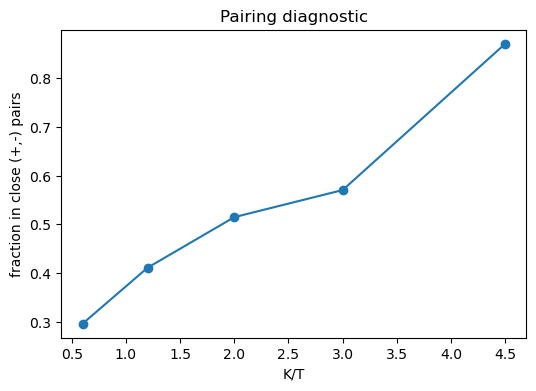

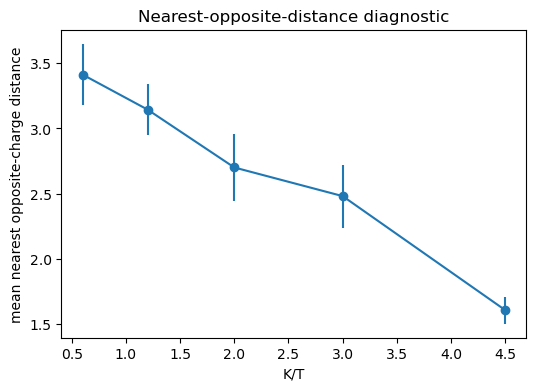

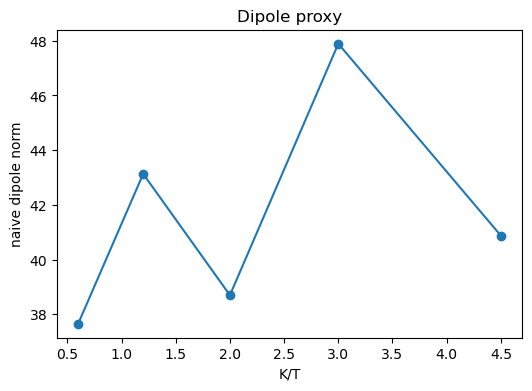

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ks, pair_fracs, marker="o")
ax.set_xlabel("K/T")
ax.set_ylabel("fraction in close (+,-) pairs")
ax.set_title("Pairing diagnostic")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(Ks, mean_nn, yerr=std_nn, marker="o")
ax.set_xlabel("K/T")
ax.set_ylabel("mean nearest opposite-charge distance")
ax.set_title("Nearest-opposite-distance diagnostic")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ks, dipoles, marker="o")
ax.set_xlabel("K/T")
ax.set_ylabel("naive dipole norm")
ax.set_title("Dipole proxy")
plt.show()

## Show one saved snapshot inline

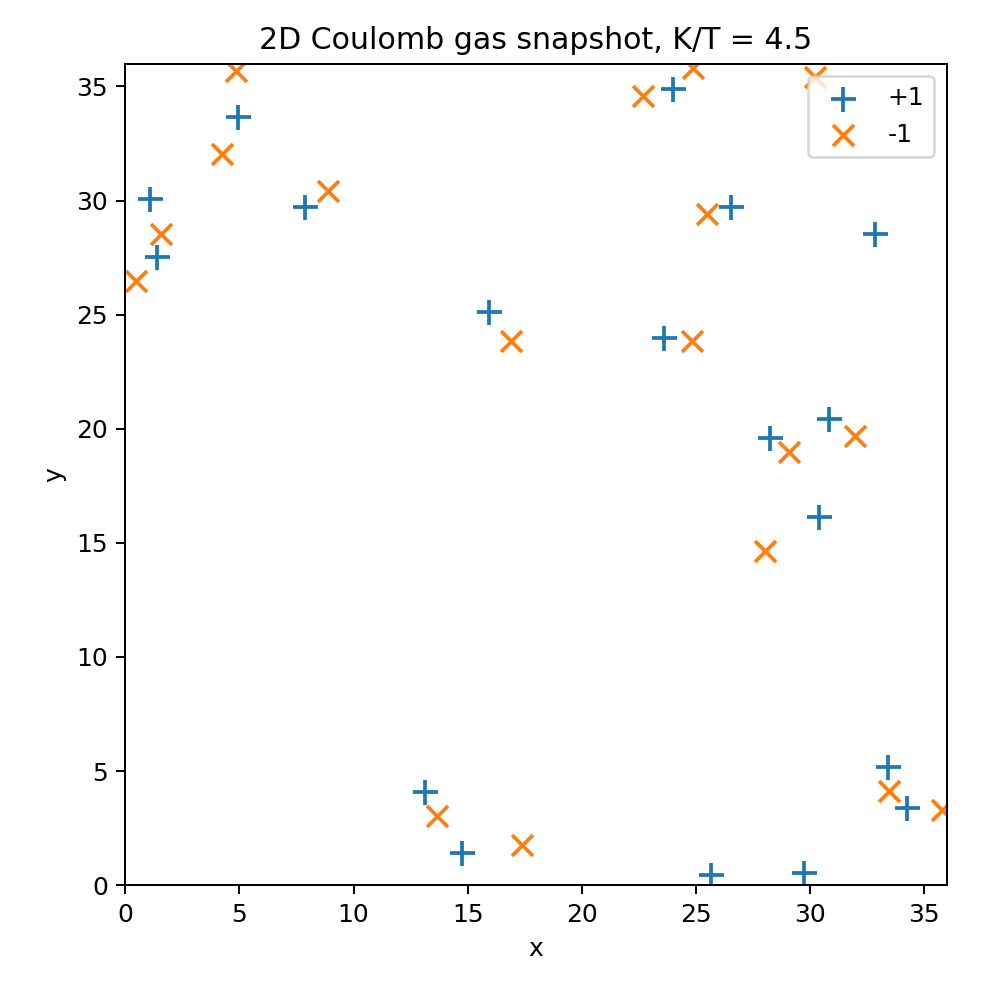

In [12]:
from IPython.display import Image, display

example_path = outdir / f"snapshot_K_{K_over_T_values[-1]:.2f}.png"
display(Image(filename=str(example_path)))

## Next upgrades if you want to get closer to the papers

1. **Grand-canonical moves**: create/annihilate neutral \((+,-)\) pairs instead of fixing particle number.
2. **Better long-range treatment**: 2D Ewald or sphere geometry.
3. **Cluster / pair moves**: important in the strongly bound regime.
4. **Dielectric observable**: estimate a proper dielectric response or inverse dielectric constant, since that is what the phase-diagram papers actually use. 
5. **Density scan**: the literature phase diagram depends on both temperature/coupling and density, not just one fixed density.

If you want, the next step should be a cleaner **grand-canonical notebook** that tries to mimic the dielectric-gas / conducting-liquid story more closely.
